In [4]:
import httpx
import time
import pandas as pd
import re
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import json
from pathlib import Path
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [5]:
model_name = "yangheng/deberta-v3-base-absa-v1.1"

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Using device:", device)

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name).to(device)
model.eval()


def aspect_sentiment(text, aspect, batch_size=16, max_length=512, stride=64):
    encoded = tokenizer(
        text,
        aspect,
        truncation=True,
        max_length=max_length,
        stride=stride,
        return_overflowing_tokens=True,
        padding=True,
        return_tensors="pt"
    )

    input_keys = ["input_ids", "attention_mask", "token_type_ids"]
    input_keys = [k for k in input_keys if k in encoded]

    all_probs = []

    with torch.inference_mode():
        n_chunks = encoded["input_ids"].shape[0]

        for start in range(0, n_chunks, batch_size):
            end = start + batch_size

            batch = {
                k: encoded[k][start:end].to(device)
                for k in input_keys
            }

            outputs = model(**batch)
            probs = F.softmax(outputs.logits, dim=-1)
            all_probs.append(probs)

    avg_probs = torch.cat(all_probs, dim=0).mean(dim=0).cpu()

    return {
        model.config.id2label[i]: float(avg_probs[i])
        for i in range(len(avg_probs))
    }

Using device: mps


/Users/mnatali/Projects/sentiment_analysis/.venv/lib/python3.13/site-packages/transformers/convert_slow_tokenizer.py:564: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(
Skipping import of cpp extensions due to incompatible torch version 2.9.1 for torchao version 0.16.0             Please see https://github.com/pytorch/ao/issues/2919 for more info
W0724 08:41:36.988000 3376 torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [6]:
print(aspect_sentiment("I love the weather here! However, datacenters are a concern. The friendly neighbors hake up for it though!", "datacenters"))
sentiment = aspect_sentiment("I love the weather here! However, datacenters are a concern. The friendly neighbors hake up for it though!", "datacenters")

post_sentiments = []
post_sentiment_degrees = []

post_sentiments.append(max(sentiment, key=sentiment.get))
post_sentiment_degrees.append(max(sentiment.values()))

print(post_sentiments[0], post_sentiment_degrees[0])

{'Negative': 0.9916238188743591, 'Neutral': 0.007077292539179325, 'Positive': 0.0012989335227757692}
Negative 0.9916238188743591


In [7]:
file_path = Path("/Users/mnatali/Projects/sentiment_analysis/testing/change_org_dataset_with_quotations.json")

with file_path.open("r", encoding="utf-8") as f:
    change_petitions = json.load(f)

In [8]:
'''
post_sentiments = []
post_sentiment_degrees = []

a = 0
for c_petition in change_petitions:
    a += 1
    text = c_petition["title"] + " " + c_petition["description"]
    sentiment = aspect_sentiment(text, "datacenters")
    post_sentiments.append(max(sentiment, key=sentiment.get))
    post_sentiment_degrees.append(max(sentiment.values()))
    print("Posts scanned:", a, end="\r")
'''

'\npost_sentiments = []\npost_sentiment_degrees = []\n\na = 0\nfor c_petition in change_petitions:\n    a += 1\n    text = c_petition["title"] + " " + c_petition["description"]\n    sentiment = aspect_sentiment(text, "datacenters")\n    post_sentiments.append(max(sentiment, key=sentiment.get))\n    post_sentiment_degrees.append(max(sentiment.values()))\n    print("Posts scanned:", a, end="\r")\n'

In [9]:
'''
sentiments_backup = post_sentiments.copy()
sentiment_degrees_backup = post_sentiment_degrees.copy()

data = {
    "sentiments": post_sentiments,
    "sentiment_degrees": post_sentiment_degrees
}

with open("change_org_sentiments_backup.json", "w") as f:
    json.dump(data, f)
'''

'\nsentiments_backup = post_sentiments.copy()\nsentiment_degrees_backup = post_sentiment_degrees.copy()\n\ndata = {\n    "sentiments": post_sentiments,\n    "sentiment_degrees": post_sentiment_degrees\n}\n\nwith open("change_org_sentiments_backup.json", "w") as f:\n    json.dump(data, f)\n'

In [10]:
file_path = Path("/Users/mnatali/Projects/sentiment_analysis/testing/change_org_sentiments_backup.json")

with file_path.open("r", encoding="utf-8") as f:
    sentiments = json.load(f)

post_sentiments = sentiments["sentiments"]
post_sentiment_degrees = sentiments["sentiment_degrees"]

In [11]:
posts = pd.DataFrame(columns=["ids", "text", "date", "signatures", "tags", "country", "state", "city", "victory", "sentiment", "degree", "AWS", "Amazon", "Google", "Microsoft", "Azure", "Meta", "Oracle", "Equinix", "Digital Realty", "IBM", "Facebook", "Apple", "QTS", "Vantage", "CyrusOne", "CoreSite"])

post_ids = []
post_texts = []
post_dates = []
post_signatures = []
post_tags = []
post_country = []
post_state = []
post_city = []
post_victory = []

a = 0

def remove_links(text):
    url_pattern = re.compile(r'\[https?://\S+\]|\(https?://\S+\)|\[www\.\S+\]|\(www\.\S+\)')
    cleaned_text = url_pattern.sub('', text)
    return cleaned_text

sample_string = "The board’s land use policy committee heard a presentation from the Department of Planning and Development about potential enhancements to data center use standards, including requiring a noise study and establishing a minimum distance from residential areas. The board had directed staff last May to provide research, findings and recommendations...  McKay said this process is designed to steer data centers into places that are most appropriate and make sure standards are set for environmental protections, noise mitigation and other issues that have people concerned. He said the county is learning from Loudoun and Prince William Counties, where data centers are becoming more and more prevalent...  [https://wjla.com/news/local/fairfax-county-considers-enhancing-data-center-guidelines-virginia-community-development-board-of-supervisors#](https://wjla.com/news/local/fairfax-county-considers-enhancing-data-center-guidelines-virginia-community-development-board-of-supervisors#)  A group of residents from the [Save Bren Mar From Data Center](https://sites.google.com/view/savebrenmar/home) group from the Mason District held up signs throughout Tuesday's legislative policy committee meeting, calling calling on the Fairfax county Supervisors to end by right data center development on commercial and industrial properties.  [https://patch.com/virginia/reston/data-center-zoning-policy-be-updated-fairfax-county-board](https://patch.com/virginia/reston/data-center-zoning-policy-be-updated-fairfax-county-board)Fairfax County considers enhancing data center guidelines"
result = remove_links(sample_string)
print(result)

for c_petition in change_petitions:
    post_ids.append(c_petition["id"])
    unclean_text = c_petition["title"] + " " + c_petition["description"]
    text = remove_links(unclean_text)
    post_texts.append(text)
    post_dates.append(c_petition["createdAt"])
    post_signatures.append(c_petition["signatures"])
    post_tags.append(c_petition["tags"])
    post_country.append(c_petition["location"]["country"])
    post_state.append(c_petition["location"]["state"])
    post_city.append(c_petition["location"]["city"])
    post_victory.append(c_petition["victory"])


posts["ids"] = post_ids
posts["text"] = post_texts
posts["date"] = post_dates
posts["signatures"] = post_signatures
posts["tags"] = post_tags
posts["country"] = post_country
posts["state"] = post_state
posts["city"] = post_city
posts["victory"] = post_victory
posts["sentiment"] = post_sentiments
posts["degree"] = post_sentiment_degrees

The board’s land use policy committee heard a presentation from the Department of Planning and Development about potential enhancements to data center use standards, including requiring a noise study and establishing a minimum distance from residential areas. The board had directed staff last May to provide research, findings and recommendations...  McKay said this process is designed to steer data centers into places that are most appropriate and make sure standards are set for environmental protections, noise mitigation and other issues that have people concerned. He said the county is learning from Loudoun and Prince William Counties, where data centers are becoming more and more prevalent...    A group of residents from the [Save Bren Mar From Data Center] group from the Mason District held up signs throughout Tuesday's legislative policy committee meeting, calling calling on the Fairfax county Supervisors to end by right data center development on commercial and industrial propert

In [12]:
posts = posts.astype({
    "ids": "string",
    "text": "string",
    "date": "string",
    "signatures": "int64",
    "tags": "object",
    "country": "string",
    "state": "string",
    "city": "string",
    "victory": "bool",
    "sentiment": "string",
    "degree": "float64",
    "AWS": "bool",
    "Amazon": "bool",
    "Google": "bool",
    "Microsoft": "bool",
    "Azure": "bool",
    "Meta": "bool",
    "Oracle": "bool",
    "Equinix": "bool",
    "Digital Realty": "bool",
    "IBM": "bool",
    "Facebook": "bool",
    "Apple": "bool",
    "QTS": "bool",
    "Vantage": "bool",
    "CyrusOne": "bool",
    "CoreSite": "bool"
})

In [13]:
company_terms = ["AWS","Amazon","Google","Microsoft","Azure","Meta","Oracle","Equinix","Digital Realty","IBM","Facebook","Apple","QTS","Vantage","CyrusOne","CoreSite"]

for c in company_terms:
    posts[c] = posts["text"].str.contains(rf'\b{re.escape(c)}\b', case=False, na=False)

posts_with_company = posts[posts[company_terms].any(axis=1)]
print(len(posts_with_company))
posts_with_company.head()

84


,ids,text,date,signatures,tags,country,state,city,victory,sentiment,...,Oracle,Equinix,Digital Realty,IBM,Facebook,Apple,QTS,Vantage,CyrusOne,CoreSite
1,491361768,Hold AI Developers Accountable for Toxic Data ...,2026-06-23T08:13:19Z,23322,"[Environmental Issues, Ethnic and Racial Minor...",US,<NA>,<NA>,False,Negative,...,False,False,False,False,False,False,False,False,False,False
10,491309264,Stop the Data Center Assault on Vizag Visakhap...,2026-05-27T12:08:14Z,12728,"[Environmental Issues, Government and Politics...",IN,<NA>,<NA>,False,Negative,...,False,False,False,False,False,False,False,False,False,False
12,491191190,Reject permits for the AI data center in Bonne...,2026-04-15T15:07:24Z,50390,"[Environmental Issues, Public Safety, Technolo...",US,MT,Missoula,False,Negative,...,False,False,False,False,False,False,False,False,False,False
27,491377862,AI Data Centers Are Destroying Alabama all don...,2026-07-03T02:02:20Z,689,"[Environmental Issues, Technology, Business an...",US,AL,<NA>,False,Negative,...,False,False,False,False,False,False,True,False,False,False
38,491252948,Protect Our Community: Enact Strong Regulation...,2026-05-17T11:11:53Z,4446,"[Public Safety, Environmental Issues, Governme...",US,PA,Fairless Hills,False,Negative,...,False,False,False,False,False,False,False,False,False,False


In [14]:
print(len(posts))
posts.head()

625


,ids,text,date,signatures,tags,country,state,city,victory,sentiment,...,Oracle,Equinix,Digital Realty,IBM,Facebook,Apple,QTS,Vantage,CyrusOne,CoreSite
0,491349675,Say NO to NRH Data Centers Next to Our Homes A...,2026-06-16T01:15:21Z,19407,"[Public Safety, Environmental Issues, Governme...",US,TX,North Richland Hills,False,Negative,...,False,False,False,False,False,False,False,False,False,False
1,491361768,Hold AI Developers Accountable for Toxic Data ...,2026-06-23T08:13:19Z,23322,"[Environmental Issues, Ethnic and Racial Minor...",US,<NA>,<NA>,False,Negative,...,False,False,False,False,False,False,False,False,False,False
2,491401881,Stop the development of Verrus Data Center in ...,2026-07-14T19:04:31Z,7150,"[Environmental Issues, Public Safety, Business...",US,OR,Salem,False,Negative,...,False,False,False,False,False,False,False,False,False,False
3,491402322,Stop the planning of a data center in South El...,2026-07-15T00:30:58Z,6001,"[Environmental Issues, Public Safety, Business...",US,IL,South Elgin,False,Negative,...,False,False,False,False,False,False,False,False,False,False
4,491361649,Ban AI Data Centers from Montana Montana is un...,2026-06-23T05:49:16Z,19508,"[Environmental Issues, Technology, Government ...",US,<NA>,<NA>,False,Negative,...,False,False,False,False,False,False,False,False,False,False


In [15]:
print(posts.columns)

Index(['ids', 'text', 'date', 'signatures', 'tags', 'country', 'state', 'city',
       'victory', 'sentiment', 'degree', 'AWS', 'Amazon', 'Google',
       'Microsoft', 'Azure', 'Meta', 'Oracle', 'Equinix', 'Digital Realty',
       'IBM', 'Facebook', 'Apple', 'QTS', 'Vantage', 'CyrusOne', 'CoreSite'],
      dtype='object')


In [16]:
## total average sentiment calculation

pos = posts.loc[posts["sentiment"] == "Positive", "degree"].sum()
neg = posts.loc[posts["sentiment"] == "Negative", "degree"].sum()
total = posts["degree"].sum()
print("Average sentiment for subset of change.org: ", (pos-neg)/total)

Average sentiment for subset of change.org:  -0.8603066014298939


In [17]:
pos = posts.loc[posts["sentiment"] == "Positive"]
neg = posts.loc[posts["sentiment"] == "Negative"]
neutral = posts.loc[posts["sentiment"] == "Neutral"]

print("Percent of posts that are neutral:", len(neutral)/len(posts))
print("Percent of posts that are negative:", len(neg)/len(posts))
print("Percent of posts that are positive:", len(pos)/len(posts))

really_pos = pos.loc[posts["degree"] > 0.90]
really_neg = neg.loc[posts["degree"] > 0.90]

if len(neg) != 0:
    print("Percent of negative posts that are really negative:", len(really_neg)/len(neg))
if len(pos) != 0:
    print("Percent of positive posts that are really positive:", len(really_pos)/len(pos))

Percent of posts that are neutral: 0.032
Percent of posts that are negative: 0.8848
Percent of posts that are positive: 0.0832
Percent of negative posts that are really negative: 0.24773960216998192
Percent of positive posts that are really positive: 0.0


In [18]:
def avg_sentiment_calculation(dataset):
    pos = dataset.loc[dataset["sentiment"] == "Positive", "degree"].sum()
    neg = dataset.loc[dataset["sentiment"] == "Negative", "degree"].sum()
    total = dataset["degree"].sum()
    if total != 0:
        return (pos-neg)/total
    else:
        return 0

posts['year'] = pd.to_datetime(posts['date']).dt.year

year_datasets = {year: posts[posts['year'] == year] for year in range(2010, 2027)}

sum = 0

for i in range(2010, 2027):
    print(f"Number of posts from {i}: ", len(year_datasets[i]))
    if(len(year_datasets[i]) != 0):
        print(f"Average sentiment for change.org posts from {i}: ", avg_sentiment_calculation(year_datasets[i]))
    sum += len(year_datasets[i])

print(sum)

Number of posts from 2010:  0
Number of posts from 2011:  0
Number of posts from 2012:  0
Number of posts from 2013:  0
Number of posts from 2014:  0
Number of posts from 2015:  0
Number of posts from 2016:  0
Number of posts from 2017:  0
Number of posts from 2018:  0
Number of posts from 2019:  0
Number of posts from 2020:  0
Number of posts from 2021:  0
Number of posts from 2022:  0
Number of posts from 2023:  1
Average sentiment for change.org posts from 2023:  -1.0
Number of posts from 2024:  1
Average sentiment for change.org posts from 2024:  -1.0
Number of posts from 2025:  85
Average sentiment for change.org posts from 2025:  -0.9561527214528419
Number of posts from 2026:  538
Average sentiment for change.org posts from 2026:  -0.8439692543065372
625


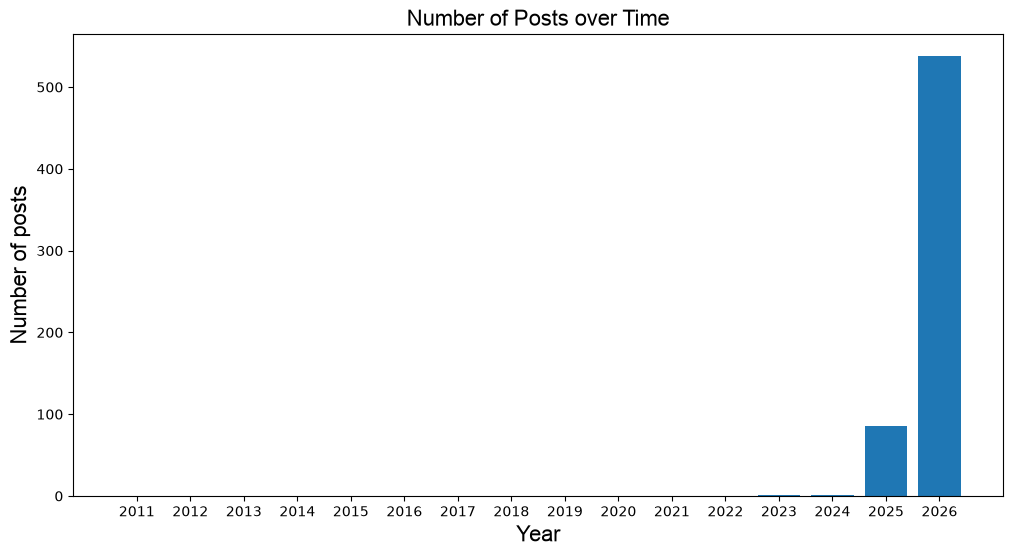

In [19]:
categories = ["2011", "2012", "2013", "2014", "2015", "2016", "2017", "2018", "2019", "2020", "2021", "2022", "2023", "2024", "2025", "2026"]
counts = [len(year_datasets[2011]), len(year_datasets[2012]), len(year_datasets[2013]), len(year_datasets[2014]), len(year_datasets[2015]), len(year_datasets[2016]), len(year_datasets[2017]), len(year_datasets[2018]), len(year_datasets[2019]), len(year_datasets[2020]), len(year_datasets[2021]), len(year_datasets[2022]), len(year_datasets[2023]), len(year_datasets[2024]), len(year_datasets[2025]), len(year_datasets[2026])]

plt.figure(figsize=(12, 6))
plt.bar(categories, counts)

plt.title(
    "Number of Posts over Time",
    fontsize=16,
    fontname="Arial"
)

plt.xlabel(
    "Year",
    fontsize=16,
    fontname="Arial"
)

plt.ylabel(
    "Number of posts",
    fontsize=16,
    fontname="Arial"
)

plt.show()

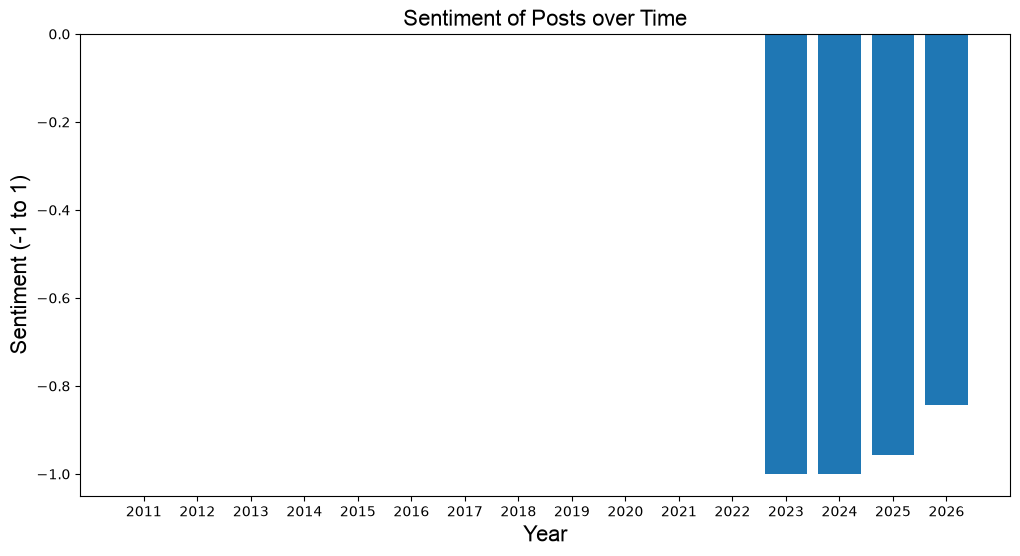

In [20]:
categories = ["2011", "2012", "2013", "2014", "2015", "2016", "2017", "2018", "2019", "2020", "2021", "2022", "2023", "2024", "2025", "2026"]
counts = [avg_sentiment_calculation(year_datasets[2011]), avg_sentiment_calculation(year_datasets[2012]), avg_sentiment_calculation(year_datasets[2013]), avg_sentiment_calculation(year_datasets[2014]), avg_sentiment_calculation(year_datasets[2015]), avg_sentiment_calculation(year_datasets[2016]), avg_sentiment_calculation(year_datasets[2017]), avg_sentiment_calculation(year_datasets[2018]), avg_sentiment_calculation(year_datasets[2019]), avg_sentiment_calculation(year_datasets[2020]), avg_sentiment_calculation(year_datasets[2021]), avg_sentiment_calculation(year_datasets[2022]), avg_sentiment_calculation(year_datasets[2023]), avg_sentiment_calculation(year_datasets[2024]), avg_sentiment_calculation(year_datasets[2025]), avg_sentiment_calculation(year_datasets[2026])]

plt.figure(figsize=(12, 6))
plt.bar(categories, counts)

plt.title(
    "Sentiment of Posts over Time",
    fontsize=16,
    fontname="Arial"
)

plt.xlabel(
    "Year",
    fontsize=16,
    fontname="Arial"
)

plt.ylabel(
    "Sentiment (-1 to 1)",
    fontsize=16,
    fontname="Arial"
)
plt.show()

In [21]:
def sentiment_by_company(company1, company2=None):
    company_posts = posts[
        (posts[company1] == True) | (posts[company2] == True) if company2 else (posts[company1] == True)
    ]
    return avg_sentiment_calculation(company_posts)

print("Number of Amazon-related posts:", len(posts[posts["AWS"] == True]) + len(posts[posts["Amazon"] == True]))
print("Average sentiment of AWS-related posts:", sentiment_by_company("AWS", "Amazon"))
print("Number of Google-related posts:", len(posts[posts["Google"] == True]))
print("Average sentiment of Google-related posts:", sentiment_by_company("Google"))
print("Number of Microsoft-related posts:", len(posts[posts["Microsoft"] == True]) + len(posts[posts["Azure"] == True]))
print("Average sentiment of Microsoft-related posts:", sentiment_by_company("Microsoft", "Azure"))
print("Number of Meta-related posts:", len(posts[posts["Meta"] == True]) + len(posts[posts["Facebook"] == True]))
print("Average sentiment of Meta-related posts:", sentiment_by_company("Meta"))
print("Number of Oracle-related posts:", len(posts[posts["Oracle"] == True]))
print("Average sentiment of Oracle-related posts:", sentiment_by_company("Oracle"))
print("Number of Equinix-related posts:", len(posts[posts["Equinix"] == True]))
print("Average sentiment of Equinix-related posts:", sentiment_by_company("Equinix"))
print("Number of Digital Realty-related posts:", len(posts[posts["Digital Realty"] == True]))
print("Average sentiment of Digital Realty-related posts:", sentiment_by_company("Digital Realty"))
print("Number of IBM-related posts:", len(posts[posts["IBM"] == True]))
print("Average sentiment of IBM-related posts:", sentiment_by_company("IBM"))
print("Number of Apple-related posts:", len(posts[posts["Apple"] == True]))
print("Average sentiment of Apple-related posts:", sentiment_by_company("Apple"))
print("Number of QTS-related posts:", len(posts[posts["QTS"] == True]))
print("Average sentiment of QTS-related posts:", sentiment_by_company("QTS"))
print("Number of Vantage-related posts:", len(posts[posts["Vantage"] == True]))
print("Average sentiment of Vantage-related posts:", sentiment_by_company("Vantage"))
print("Number of CyrusOne-related posts:", len(posts[posts["CyrusOne"] == True]))
print("Average sentiment of CyrusOne-related posts:", sentiment_by_company("CyrusOne"))
print("Number of CoreSite-related posts:", len(posts[posts["CoreSite"] == True]))
print("Average sentiment of CoreSite-related posts:", sentiment_by_company("CoreSite"))

Number of Amazon-related posts:

 19
Average sentiment of AWS-related posts: -0.9015490241965702
Number of Google-related posts: 23
Average sentiment of Google-related posts: -0.9401932651565487
Number of Microsoft-related posts: 16
Average sentiment of Microsoft-related posts: -0.8155560690788565
Number of Meta-related posts: 45
Average sentiment of Meta-related posts: -0.848640173759603
Number of Oracle-related posts: 2
Average sentiment of Oracle-related posts: -1.0
Number of Equinix-related posts: 1
Average sentiment of Equinix-related posts: -1.0
Number of Digital Realty-related posts: 0
Average sentiment of Digital Realty-related posts: 0
Number of IBM-related posts: 3
Average sentiment of IBM-related posts: -1.0
Number of Apple-related posts: 2
Average sentiment of Apple-related posts: -1.0
Number of QTS-related posts: 4
Average sentiment of QTS-related posts: -1.0
Number of Vantage-related posts: 4
Average sentiment of Vantage-related posts: -0.590864177537199
Number of CyrusOne-related posts: 1
Average sentim

In [22]:
def analysis_of_viral_posts(min):
    viral_posts = posts.loc[posts["signatures"] >= min]
    non_viral_posts = posts.loc[posts["signatures"] < min]
    print("What's considered viral: posts with over", min, "signatures")
    print("Number of viral posts:", len(viral_posts))
    print("Average sentiment of viral posts:", avg_sentiment_calculation(viral_posts))
    print("Average sentiment of non-viral posts:", avg_sentiment_calculation(non_viral_posts))
    print("Amount percent of viral posts that are polar (degree) > 0.90: ", len(viral_posts.loc[viral_posts["degree"] > 0.90])/len(viral_posts))
    print("Percent of viral posts that are negative: ", (len(viral_posts.loc[viral_posts["sentiment"] == "Negative"]))/len(viral_posts))
    print("Percent of non-viral posts that are negative: ", (len(non_viral_posts.loc[non_viral_posts["sentiment"] == "Negative"]))/(len(non_viral_posts)))

analysis_of_viral_posts(1000)
print("\n")
analysis_of_viral_posts(2000)
print("\n")
analysis_of_viral_posts(5000)
print("\n")
analysis_of_viral_posts(10000)

What's considered viral: posts with over 1000 signatures
Number of viral posts: 269
Average sentiment of viral posts: -0.8644651803337802
Average sentiment of non-viral posts: -0.8572058639668569
Amount percent of viral posts that are polar (degree) > 0.90:  0.2342007434944238
Percent of viral posts that are negative:  0.8884758364312267
Percent of non-viral posts that are negative:  0.8820224719101124


What's considered viral: posts with over 2000 signatures
Number of viral posts: 163
Average sentiment of viral posts: -0.9119526141939633
Average sentiment of non-viral posts: -0.8421680210333279
Amount percent of viral posts that are polar (degree) > 0.90:  0.24539877300613497
Percent of viral posts that are negative:  0.9263803680981595
Percent of non-viral posts that are negative:  0.8701298701298701


What's considered viral: posts with over 5000 signatures
Number of viral posts: 62
Average sentiment of viral posts: -0.8933715068132559
Average sentiment of non-viral posts: -0.85673

In [30]:
posts_with_country = posts[posts["country"].notna()]
posts_without_country = posts[posts["country"].isna()]
print(len(posts_with_country))

posts_with_state = posts[posts["state"].notna()]
posts_without_state = posts[posts["state"].isna()]
print(len(posts_with_state))

posts_with_city = posts[posts["city"].notna()]
posts_without_city = posts[posts["city"].isna()]
print(len(posts_with_city))


unique_countries = posts["country"].dropna().unique()
unique_states = posts["state"].dropna().unique()
unique_cities = posts["city"].dropna().unique()

print("Unique countries:", unique_countries)
print("Unique states:", unique_states)
print("Unique cities:", unique_cities)

'''
Out of 625 petitions, there are petitions from the United States, India, Australia, Trinidad and Tobago, Canada, Malaysia, 
and South Africa, 53 states, and 214 cities (meaning that very few petitions are from the same city but many are from the 
same states)
'''

def sentiment_and_count_by_location(location_type, location_name):
    if location_type == "country":
        location_posts = posts[posts["country"] == location_name]
    elif location_type == "state":
        location_posts = posts[posts["state"] == location_name]
    elif location_type == "city":
        location_posts = posts[posts["city"] == location_name]

    return avg_sentiment_calculation(location_posts), len(location_posts)

print("Average sentiment of posts from the United States:", sentiment_and_count_by_location("country", "US")[0])
print("Count of posts from the United States:", sentiment_and_count_by_location("country", "US")[1])

print("Average sentiment of posts from the Texas:", sentiment_and_count_by_location("state", "TX")[0])
print("Count of posts from the Texas:", sentiment_and_count_by_location("state", "TX")[1])

625
537
251
Unique countries: <StringArray>
['US', 'IN', 'AU', 'TT', 'CA', 'MY', 'ZA']
Length: 7, dtype: string
Unique states: <StringArray>
[                       'TX',                        'OR',
                        'IL',                        'NY',
                        'CA',                        'MD',
                        'MT',                        'IN',
                        'VA',                        'IA',
                        'WI',                        'KS',
                        'CO',                        'AZ',
                        'PA',                        'AL',
                        'TN',                        'FL',
                        'GA', 'Port of Spain Corporation',
                        'MN',                        'NV',
                        'WA',                        'WV',
                        'CT',                        'KY',
                        'OH',                        'MI',
                        'NJ',    